In [1]:
# ============================================
# White Blood Cell Classification
# Using Deep Learning - Transfer Learning with ResNet50
#
# Student: Yanir Karpis 318933371
#
# Dataset: Blood Cell Images
# Source: kaggle.com/datasets/paultimothymooney/blood-cells
# ============================================

In [2]:
# Install required libraries
!pip install gdown

# Import all necessary libraries
import gdown
import os
import zipfile
import torch
import torchvision
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns
print("All libraries imported successfully!")


# Download dataset from Google Drive (public link)
folder_id = "1vw0MIw6cN2GMWqIM7avqURNVhH9ViEuc"
output = "blood_cells.zip"

gdown.download_folder(
    f"https://drive.google.com/drive/folders/{folder_id}",
    quiet=False,
    use_cookies=False
)

print("Download complete!")

# Unzip the dataset
zip_path = "/content/blood_cells_project/blood cells images.zip"
extract_path = "/content/blood_cells_project/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzip complete!")
print("Files extracted:")
for item in os.listdir(extract_path):
    print(" -", item)

# define paths
base_path = "/content/blood_cells_project/dataset2-master/dataset2-master/images"

train_path = os.path.join(base_path, "TRAIN")
val_path   = os.path.join(base_path, "TEST_SIMPLE")
test_path  = os.path.join(base_path, "TEST")

# Check paths exist and count images per class
for split_name, split_path in [("TRAIN", train_path), ("VALIDATION", val_path), ("TEST", test_path)]:
    print(f"\n{split_name}:")
    total = 0
    for class_name in sorted(os.listdir(split_path)):
        class_dir = os.path.join(split_path, class_name)
        if os.path.isdir(class_dir):
            count = len(os.listdir(class_dir))
            total += count
            print(f"  {class_name}: {count} images")
    print(f"  TOTAL: {total} images")

All libraries imported successfully!


Retrieving folder contents


Processing file 1uFj2nCaZVduAOdWloelTNbeZ3NgMuTvD blood cells images.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1uFj2nCaZVduAOdWloelTNbeZ3NgMuTvD
From (redirected): https://drive.google.com/uc?id=1uFj2nCaZVduAOdWloelTNbeZ3NgMuTvD&confirm=t&uuid=a865a639-6b8b-4bf3-9a05-a2a35306c0c6
To: /content/blood_cells_project/blood cells images.zip
100%|██████████| 113M/113M [00:01<00:00, 59.3MB/s]
Download completed


Download complete!
Unzip complete!
Files extracted:
 - blood cells images.zip
 - dataset-master
 - dataset2-master

TRAIN:
  EOSINOPHIL: 2497 images
  LYMPHOCYTE: 2483 images
  MONOCYTE: 2478 images
  NEUTROPHIL: 2499 images
  TOTAL: 9957 images

VALIDATION:
  EOSINOPHIL: 13 images
  LYMPHOCYTE: 6 images
  MONOCYTE: 4 images
  NEUTROPHIL: 48 images
  TOTAL: 71 images

TEST:
  EOSINOPHIL: 623 images
  LYMPHOCYTE: 620 images
  MONOCYTE: 620 images
  NEUTROPHIL: 624 images
  TOTAL: 2487 images


In [3]:
# Define image transformations
# Training: preprocessing + augmentation
# Validation/Test: preprocessing only (no augmentation)
# We only have ~10,000 images — too small to train a good CNN from scratch
# ResNet50 was already trained on 1 million+ images — it already knows how to detect edges, shapes, textures

train_transforms = transforms.Compose([
    transforms.Resize(256),                  # resize shorter side to 256, keeps aspect ratio
    transforms.CenterCrop(224),              # crop center to 224x224 — this is the standard ImageNet recipe
                                             # avoids squishing the image, preserving cell shapes
    transforms.RandomHorizontalFlip(),       # random flip for augmentation
    transforms.RandomVerticalFlip(),         # random flip for augmentation
    transforms.RandomRotation(15),           # random rotation +-15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # color augmentation
    transforms.ToTensor(),                   # convert image to tensor
    transforms.Normalize(                    # normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize(256),                  # resize shorter side to 256, keeps aspect ratio
    transforms.CenterCrop(224),              # crop center to 224x224 — same as training for consistency
    transforms.ToTensor(),                   # convert image to tensor
    transforms.Normalize(                    # normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined successfully!")

from torch.utils.data import random_split, Subset

# Set a fixed seed so the train/val split is the same every run
torch.manual_seed(42)

# load the training folder TWICE with different transforms
# If we split one dataset, both train and val share the same transform object
# That means val images would also get randomly flipped/rotated — giving
# artificially low val loss and making early stopping fire at the wrong time
full_train_aug   = datasets.ImageFolder(root=train_path, transform=train_transforms)  # for training
full_train_clean = datasets.ImageFolder(root=train_path, transform=test_transforms)   # for validation

# 80% train, 20% validation
train_size = int(0.8 * len(full_train_aug))
val_size   = len(full_train_aug) - train_size

# Create index lists and split them
indices       = list(range(len(full_train_aug)))
train_indices = indices[:train_size]
val_indices   = indices[train_size:]

# Each subset gets the right transforms
train_dataset = Subset(full_train_aug,   train_indices)   # augmented images for training
val_dataset   = Subset(full_train_clean, val_indices)     # clean images for validation (same as test)

# Keep full_train_dataset pointing to the augmented version (used later for class names)
full_train_dataset = full_train_aug

# Load test dataset with clean transforms
test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transforms
)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"\nClasses: {full_train_dataset.classes}")


Transforms defined successfully!
Training samples:   7965
Validation samples: 1992
Test samples:       2487

Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [4]:
# DataLoaders feed batches of images to the model during training
# batch_size=32 means the model sees 32 images at a time

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

# Load ResNet50 pretrained on ImageNet
# pretrained=True means we use weights already learned from millions of images
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers — we don't want to change what ResNet50 already learned
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer with our own
# Original ResNet50 outputs 1000 classes (ImageNet)
# We change it to output 4 classes (our cell types)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model ready!")
print(f"Using device: {device}")
print(f"Final layer: {model.fc}")

Train batches:      249
Validation batches: 63
Test batches:       78
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s]


Model ready!
Using device: cuda
Final layer: Linear(in_features=2048, out_features=4, bias=True)


In [6]:
# Cross-Entropy loss — standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer — only train the final layer we added
# we only pass model.fc.parameters() because all other layers are frozen
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

#Adam is an improved version of basic gradient descent
#lr=0.001 → bigger steps → faster learning → okay when only training one layer

print("Loss function: Cross-Entropy")
print("Optimizer: Adam")
print("Learning rate: 0.001")

# Training loop
num_epochs = 20
best_val_loss = float('inf')
patience = 5  # early stopping patience
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting training...\n")

for epoch in range(num_epochs):
    # ── TRAINING PHASE ──
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # clear gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)  # calculate loss
        loss.backward()              # backpropagation
        optimizer.step()             # update weights

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # ── VALIDATION PHASE ──
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # no gradient calculation needed for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate averages
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = 100 * train_correct / train_total
    val_acc        = 100 * val_correct   / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early stopping — stop if validation loss doesn't improve
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')  # save best model
        patience_counter = 0
        print(f"  ✓ Best model saved!")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTraining complete!")

Loss function: Cross-Entropy
Optimizer: Adam
Learning rate: 0.001
Starting training...

Epoch [1/20] Train Loss: 0.6618 | Train Acc: 78.71% | Val Loss: 1.3939 | Val Acc: 25.55%
  ✓ Best model saved!
Epoch [2/20] Train Loss: 0.5848 | Train Acc: 81.51% | Val Loss: 1.2890 | Val Acc: 34.54%
  ✓ Best model saved!
Epoch [3/20] Train Loss: 0.5312 | Train Acc: 83.11% | Val Loss: 1.2636 | Val Acc: 37.95%
  ✓ Best model saved!
Epoch [4/20] Train Loss: 0.5095 | Train Acc: 83.85% | Val Loss: 1.3089 | Val Acc: 34.89%
  No improvement (1/5)
Epoch [5/20] Train Loss: 0.4841 | Train Acc: 84.58% | Val Loss: 1.3857 | Val Acc: 34.44%
  No improvement (2/5)
Epoch [6/20] Train Loss: 0.4531 | Train Acc: 85.24% | Val Loss: 1.3498 | Val Acc: 34.24%
  No improvement (3/5)
Epoch [7/20] Train Loss: 0.4453 | Train Acc: 85.31% | Val Loss: 1.1500 | Val Acc: 43.83%
  ✓ Best model saved!
Epoch [8/20] Train Loss: 0.4371 | Train Acc: 85.73% | Val Loss: 1.4359 | Val Acc: 30.67%
  No improvement (1/5)
Epoch [9/20] Train L

Test Accuracy: 65.50%

F1 Score per class:
  EOSINOPHIL: 0.5740
  LYMPHOCYTE: 0.8043
  MONOCYTE: 0.6295
  NEUTROPHIL: 0.6255

Macro F1: 0.6584


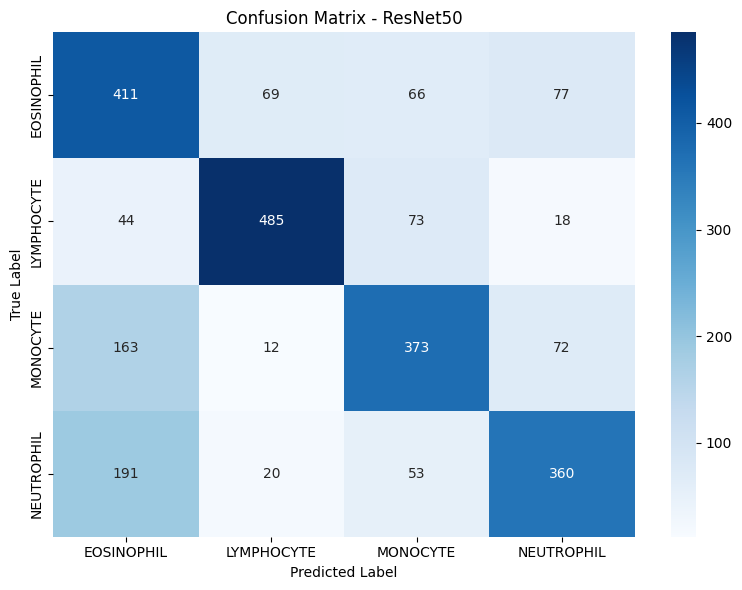

Confusion matrix saved!


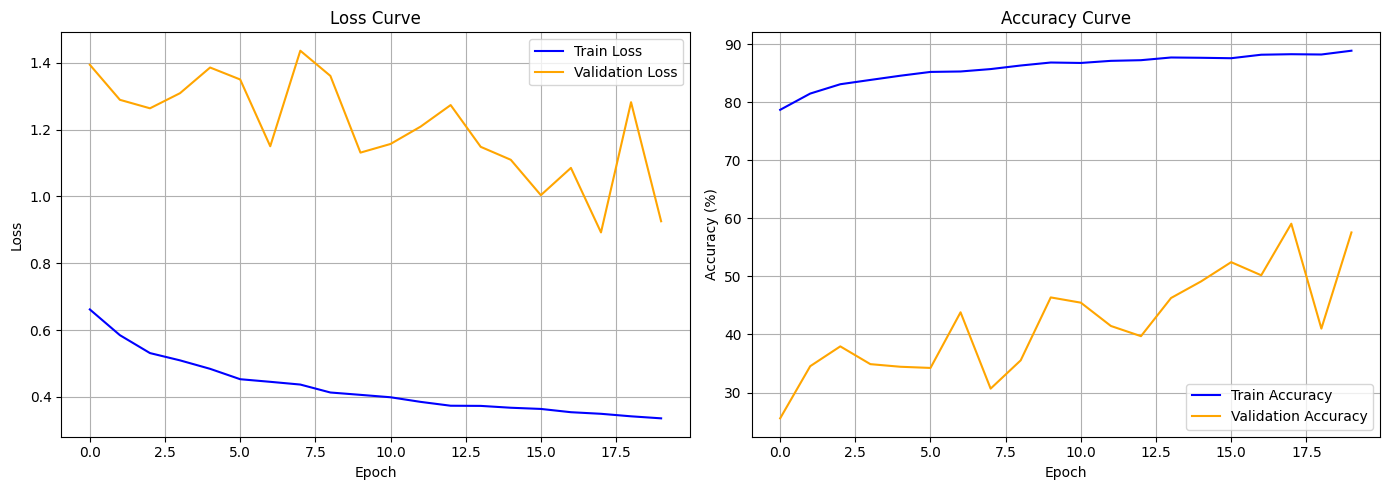

Learning curves saved!


In [7]:
# Load the best model we saved during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Evaluate on test set
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
correct = sum(p == l for p, l in zip(all_predictions, all_labels))
test_accuracy = 100 * correct / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

# F1 score per class
classes = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
f1 = f1_score(all_labels, all_predictions, average=None)
print("\nF1 Score per class:")
for cls, score in zip(classes, f1):
    print(f"  {cls}: {score:.4f}")
print(f"\nMacro F1: {f1_score(all_labels, all_predictions, average='macro'):.4f}")

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - ResNet50')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

# Plot training and validation loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Validation Loss', color='orange')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(val_accuracies, label='Validation Accuracy', color='orange')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()
print("Learning curves saved!")

In [8]:
# Model 1 showed overfitting - validation accuracy was high (86%)
# but test accuracy was low (60%).

In [9]:
# ============================================
# MODEL 2: Fine-tuned ResNet50
# Improvements over Model 1:
# 1. Unfreeze layer3 + layer4 - learn blood cell specific features at multiple depths
# 2. Dropout - prevent overfitting
# 3. Weight decay - keep model simple
# 4. LR scheduler - reduces learning rate when progress stalls
# ============================================

# Reload fresh ResNet50 with pretrained ImageNet weights
model2 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze all layers first — preserve the general features ResNet already learned
for param in model2.parameters():
    param.requires_grad = False

# Unfreeze layer3 and layer4 — deeper layers that learn complex shapes
# layer4 = highest-level features (object parts, overall cell type)
# layer3 = mid-level features (textures, cell boundaries)
for param in model2.layer3.parameters():
    param.requires_grad = True
for param in model2.layer4.parameters():
    param.requires_grad = True

# Replace the final classification layer
# Original ResNet50 outputs 1000 classes (ImageNet) — we change it to 4 classes
num_features = model2.fc.in_features
model2.fc = nn.Sequential(
    nn.Dropout(0.5),           # randomly drops 50% of neurons — prevents memorizing training data
    nn.Linear(num_features, 4) # 4 output neurons, one per blood cell class
)

model2 = model2.to(device)

# Adam optimizer with weight decay
# filter(requires_grad) makes sure we only update unfrozen layers (layer3, layer4, fc)
# lr=0.0001 — smaller than Model 1, needed when fine-tuning pretrained layers
#             (too big a step would destroy the pretrained weights)
# weight_decay=0.0001 — L2 regularization: penalizes large weights to keep the model general
optimizer2 = optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

# Learning rate scheduler — reduces lr by 50% if val loss stops improving for 3 epochs
# Lets the model take bigger steps early on and smaller, more careful steps later
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='min', factor=0.5, patience=3)

print("Model 2 ready!")
print("Trainable layers: layer3, layer4, fc")
print("Final layer:", model2.fc)


Model 2 ready!
Trainable layers: layer3, layer4, fc
Final layer: Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)


In [10]:
# ============================================
# Training Model 2
# ============================================

num_epochs_m2 = 20       # more epochs since we are training more layers
best_val_loss_m2 = float('inf')
patience_counter_m2 = 0
patience_m2 = 5           # slightly more patience to let the scheduler kick in

m2_train_losses = []
m2_val_losses = []
m2_train_accuracies = []
m2_val_accuracies = []

print("Training Model 2...\n")

for epoch in range(num_epochs_m2):
    # ── TRAINING PHASE ──
    model2.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer2.zero_grad()            # clear gradients from last step
        outputs = model2(images)          # forward pass through the network
        loss = criterion(outputs, labels) # calculate how wrong the predictions are
        loss.backward()                   # backpropagation — compute gradients
        optimizer2.step()                 # update weights using those gradients

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # ── VALIDATION PHASE ──
    model2.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # no gradient calculation needed — we are just measuring performance
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc = 100 * train_correct / train_total
    val_acc   = 100 * val_correct   / val_total

    m2_train_losses.append(avg_train_loss)
    m2_val_losses.append(avg_val_loss)
    m2_train_accuracies.append(train_acc)
    m2_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs_m2}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Step the scheduler — if val loss has not improved in 3 epochs, lr is halved
    scheduler2.step(avg_val_loss)

    # Early stopping — save the best model and stop if val loss stalls
    if avg_val_loss < best_val_loss_m2:
        best_val_loss_m2 = avg_val_loss
        torch.save(model2.state_dict(), 'best_model2.pth')  # save best checkpoint
        patience_counter_m2 = 0
        print(f"  ✓ Best model saved!")
    else:
        patience_counter_m2 += 1
        print(f"  No improvement ({patience_counter_m2}/{patience_m2})")
        if patience_counter_m2 >= patience_m2:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("\nTraining complete!")


Training Model 2...

Epoch [1/20] Train Loss: 0.4147 | Train Acc: 84.56% | Val Loss: 0.4135 | Val Acc: 80.12%
  ✓ Best model saved!
Epoch [2/20] Train Loss: 0.0771 | Train Acc: 97.49% | Val Loss: 0.2319 | Val Acc: 91.06%
  ✓ Best model saved!
Epoch [3/20] Train Loss: 0.0346 | Train Acc: 99.00% | Val Loss: 0.0386 | Val Acc: 98.59%
  ✓ Best model saved!
Epoch [4/20] Train Loss: 0.0254 | Train Acc: 99.27% | Val Loss: 0.1899 | Val Acc: 93.52%
  No improvement (1/5)
Epoch [5/20] Train Loss: 0.0163 | Train Acc: 99.61% | Val Loss: 0.2240 | Val Acc: 93.12%
  No improvement (2/5)
Epoch [6/20] Train Loss: 0.0272 | Train Acc: 99.11% | Val Loss: 0.0541 | Val Acc: 98.39%
  No improvement (3/5)
Epoch [7/20] Train Loss: 0.0156 | Train Acc: 99.57% | Val Loss: 0.1086 | Val Acc: 96.44%
  No improvement (4/5)
Epoch [8/20] Train Loss: 0.0080 | Train Acc: 99.74% | Val Loss: 0.0346 | Val Acc: 98.80%
  ✓ Best model saved!
Epoch [9/20] Train Loss: 0.0041 | Train Acc: 99.91% | Val Loss: 0.0222 | Val Acc: 99.15

Test Accuracy (Model 2): 85.93%

F1 Score per class (Model 2):
  EOSINOPHIL: 0.8484
  LYMPHOCYTE: 0.9836
  MONOCYTE: 0.8571
  NEUTROPHIL: 0.7672

Macro F1 (Model 2): 0.8641


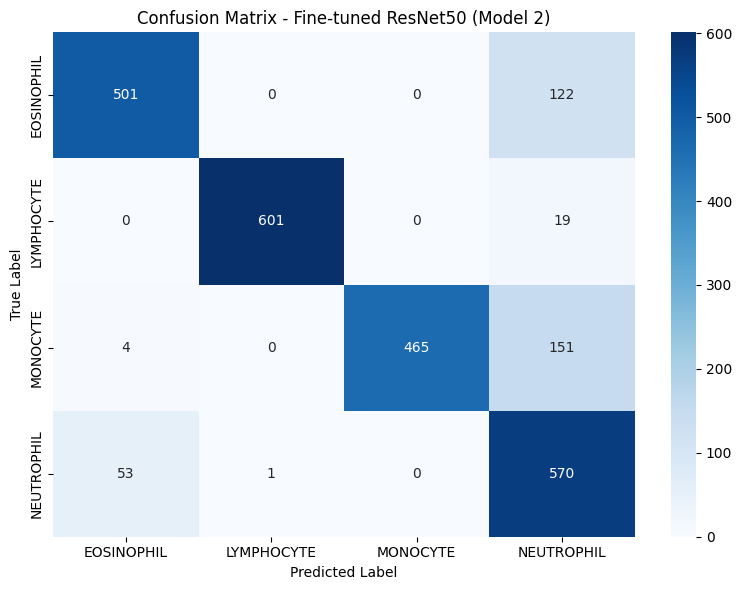

Confusion matrix for Model 2 saved!


In [11]:
model2.load_state_dict(torch.load('best_model2.pth'))
model2.eval()

all_predictions_m2 = []
all_labels_m2 = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions_m2.extend(predicted.cpu().numpy())
        all_labels_m2.extend(labels.cpu().numpy())

correct_m2 = sum(p == l for p, l in zip(all_predictions_m2, all_labels_m2))
test_accuracy_m2 = 100 * correct_m2 / len(all_labels_m2)
print(f"Test Accuracy (Model 2): {test_accuracy_m2:.2f}%")

classes = full_train_dataset.classes
f1_m2 = f1_score(all_labels_m2, all_predictions_m2, average=None)
print("\nF1 Score per class (Model 2):")
for cls, score in zip(classes, f1_m2):
    print(f"  {cls}: {score:.4f}")
print(f"\nMacro F1 (Model 2): {f1_score(all_labels_m2, all_predictions_m2, average='macro'):.4f}")

cm_m2 = confusion_matrix(all_labels_m2, all_predictions_m2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_m2, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Fine-tuned ResNet50 (Model 2)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_model2.png')
plt.show()
print("Confusion matrix for Model 2 saved!")

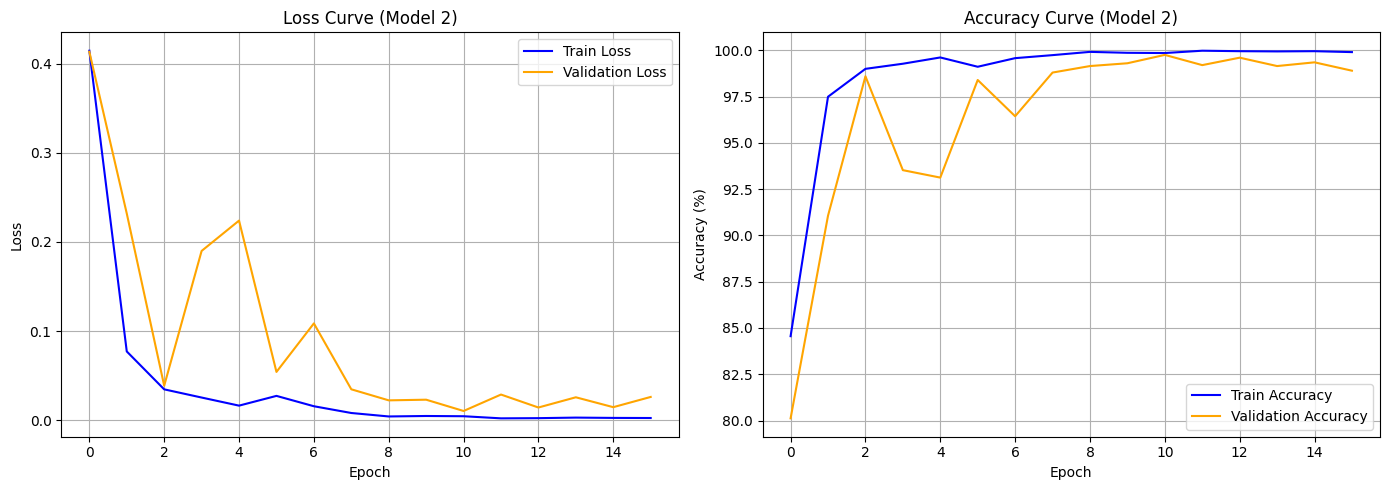

Learning curves for Model 2 saved!


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(m2_train_losses, label='Train Loss', color='blue')
ax1.plot(m2_val_losses, label='Validation Loss', color='orange')
ax1.set_title('Loss Curve (Model 2)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(m2_train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(m2_val_accuracies, label='Validation Accuracy', color='orange')
ax2.set_title('Accuracy Curve (Model 2)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('learning_curves_model2.png')
plt.show()
print("Learning curves for Model 2 saved!")

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import torch.nn.functional as F

# 1. Set models to evaluation mode
model.eval()
model2.eval()

# 2. Obtain prediction probabilities for Model 1
all_labels_model1 = []
all_probs_model1  = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        all_labels_model1.extend(labels.cpu().numpy())
        all_probs_model1.extend(probabilities.cpu().numpy())

print("Model 1 predictions and probabilities obtained.")

Model 1 predictions and probabilities obtained.


In [14]:
all_labels_model2 = []
all_probs_model2  = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model2(images)
        probabilities = F.softmax(outputs, dim=1)
        all_labels_model2.extend(labels.cpu().numpy())
        all_probs_model2.extend(probabilities.cpu().numpy())

print("Model 2 predictions and probabilities obtained.")

# Convert to numpy arrays
all_labels_model1 = np.array(all_labels_model1)
all_probs_model1 = np.array(all_probs_model1)
all_labels_model2 = np.array(all_labels_model2)
all_probs_model2 = np.array(all_probs_model2)

# Convert true labels to one-hot encoded format for multi-class ROC
label_binarizer = LabelBinarizer()
label_binarizer.fit(all_labels_model1)

true_labels_one_hot_model1 = label_binarizer.transform(all_labels_model1)
true_labels_one_hot_model2 = label_binarizer.transform(all_labels_model2)

print("True labels binarized for ROC calculation.")

Model 2 predictions and probabilities obtained.
True labels binarized for ROC calculation.


In [15]:
n_classes = len(full_train_dataset.classes)

# Calculate ROC for Model 1
roc_auc_model1 = dict()
fpr_model1 = dict()
tpr_model1 = dict()

for i in range(n_classes):
    fpr_model1[i], tpr_model1[i], _ = roc_curve(true_labels_one_hot_model1[:, i], all_probs_model1[:, i])
    roc_auc_model1[i] = auc(fpr_model1[i], tpr_model1[i])

print("ROC curves and AUC scores calculated for Model 1.")


ROC curves and AUC scores calculated for Model 1.


In [16]:
roc_auc_model2 = dict()
fpr_model2 = dict()
tpr_model2 = dict()

for i in range(n_classes):
    fpr_model2[i], tpr_model2[i], _ = roc_curve(true_labels_one_hot_model2[:, i], all_probs_model2[:, i])
    roc_auc_model2[i] = auc(fpr_model2[i], tpr_model2[i])

print("ROC curves and AUC scores calculated for Model 2.")

ROC curves and AUC scores calculated for Model 2.


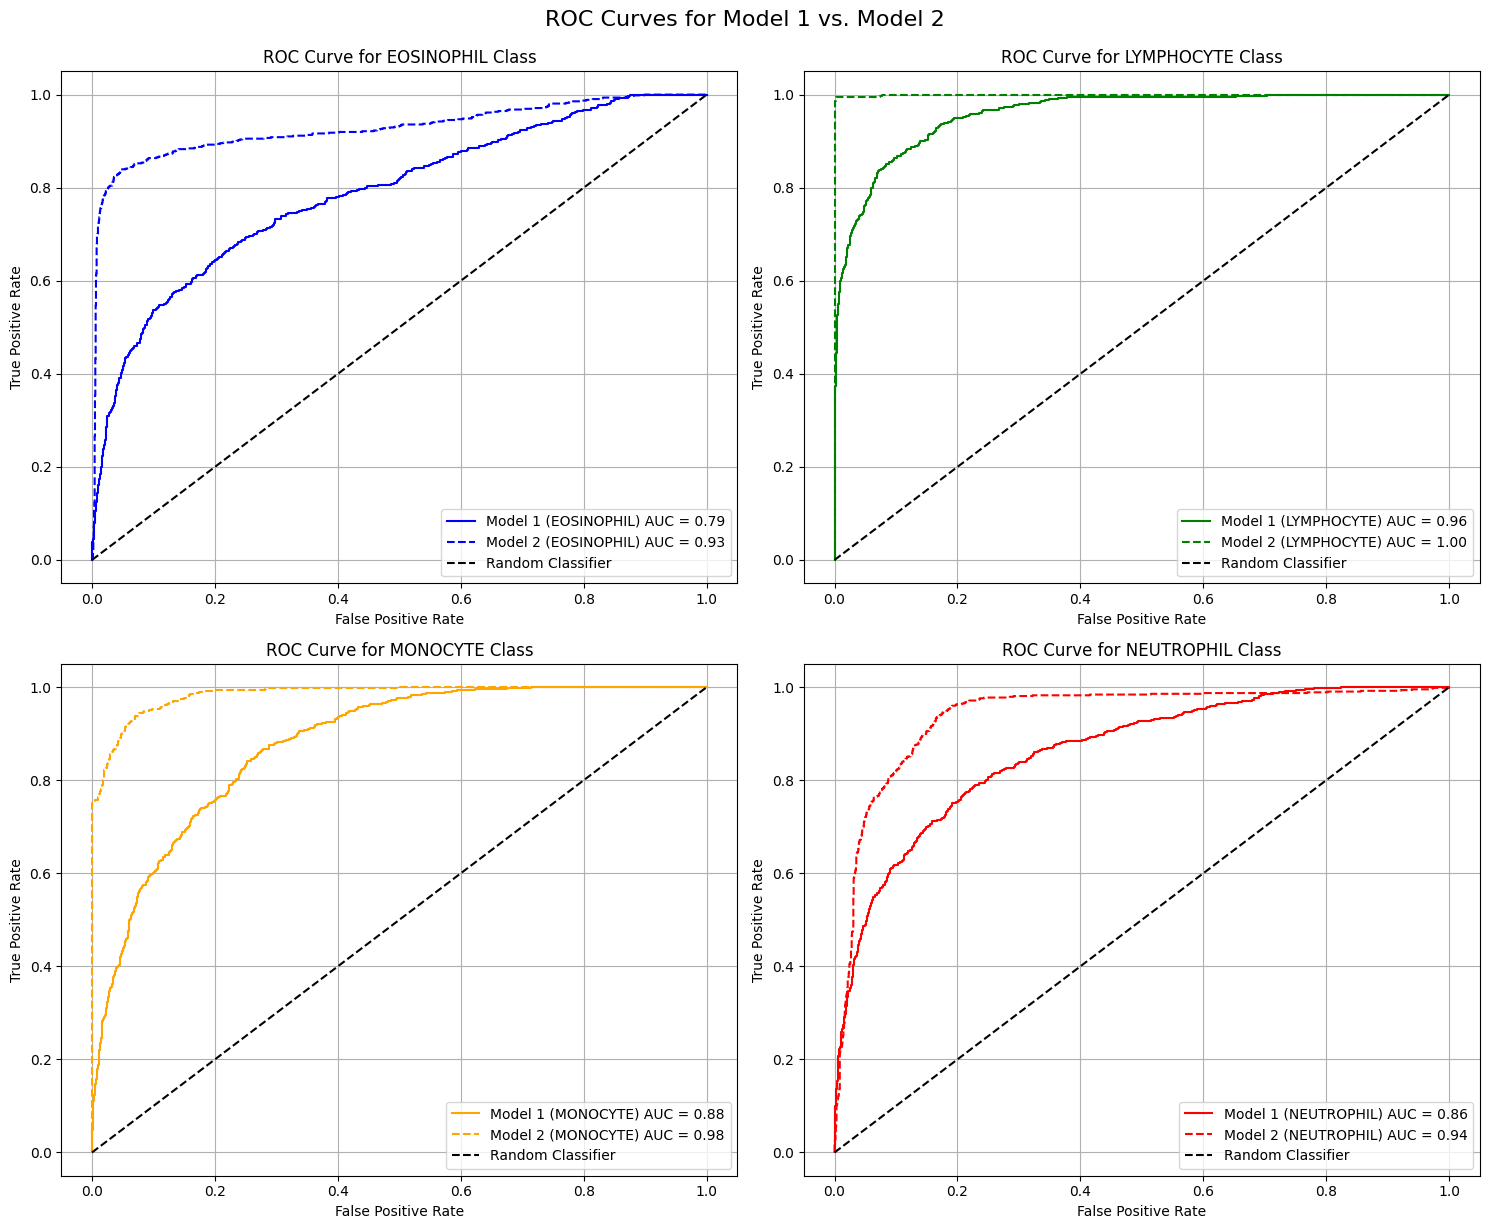

ROC curve comparison plot generated and saved!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2x2 array of axes for easy iteration

classes = full_train_dataset.classes
colors = ['blue', 'green', 'orange', 'red']

for i, cls_name in enumerate(classes):
    ax = axes[i]

    # Plot ROC curve for Model 1
    ax.plot(fpr_model1[i], tpr_model1[i], color=colors[i], label=f'Model 1 ({cls_name}) AUC = {roc_auc_model1[i]:.2f}')

    # Plot ROC curve for Model 2
    ax.plot(fpr_model2[i], tpr_model2[i], color=colors[i], linestyle='--', label=f'Model 2 ({cls_name}) AUC = {roc_auc_model2[i]:.2f}')

    # Plot random classifier line
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve for {cls_name} Class')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.suptitle('ROC Curves for Model 1 vs. Model 2', y=1.02, fontsize=16)
plt.savefig('roc_curve_comparison.png')
plt.show()

print("ROC curve comparison plot generated and saved!")

        FINAL RESULTS SUMMARY
Model                            Test Acc   Macro F1
-------------------------------------------------------
Model 1 - Frozen ResNet50          65.50%     0.6584
Model 2 - Fine-tuned ResNet50      85.93%     0.8641


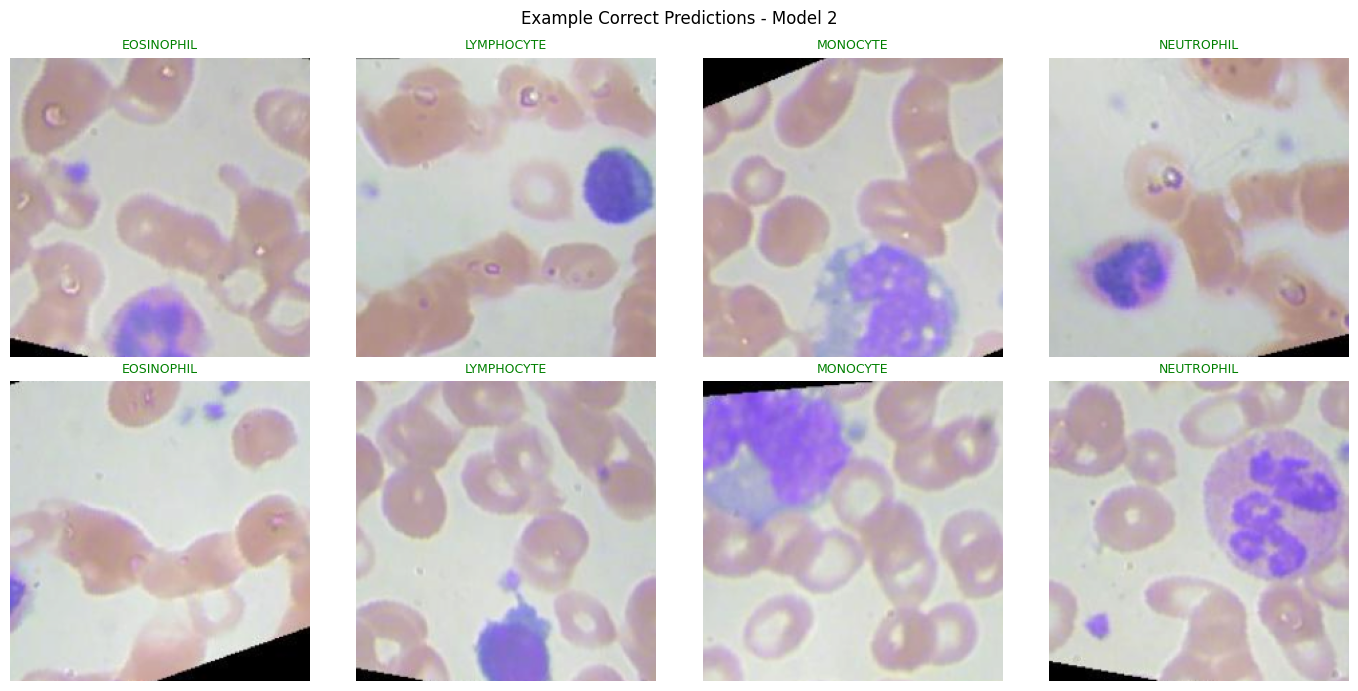

In [18]:
# Final comparison summary
print("=" * 55)
print("        FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Model':<30} {'Test Acc':>10} {'Macro F1':>10}")
print("-" * 55)
print(f"{'Model 1 - Frozen ResNet50':<30} {test_accuracy:>9.2f}% {f1_score(all_labels, all_predictions, average='macro'):>10.4f}")
print(f"{'Model 2 - Fine-tuned ResNet50':<30} {test_accuracy_m2:>9.2f}% {f1_score(all_labels_m2, all_predictions_m2, average='macro'):>10.4f}")
print("=" * 55)

# Show correct predictions — 2 examples per class
model2.eval()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

found = {cls: [] for cls in full_train_dataset.classes}

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model2(images.to(device))
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            true_l = labels[i].item()
            pred_l = predicted[i].item()
            cls_name = full_train_dataset.classes[true_l]
            if true_l == pred_l and len(found[cls_name]) < 2:
                img = images[i].numpy().transpose(1, 2, 0)
                img = np.clip(std * img + mean, 0, 1)
                found[cls_name].append(img)
        if all(len(v) == 2 for v in found.values()):
            break

for col, cls_name in enumerate(full_train_dataset.classes):
    for row in range(2):
        axes[row][col].imshow(found[cls_name][row])
        axes[row][col].set_title(cls_name, color='green', fontsize=9)
        axes[row][col].axis('off')

plt.suptitle('Example Correct Predictions - Model 2', fontsize=12)
plt.tight_layout()
plt.savefig('example_predictions.png')
plt.show()